In [1]:
from __future__ import annotations

import math
import os
import sys
import time as t
from datetime import date
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns

sys.path.append("../0-data") 
from archi_dict import archi_sorghum as archi_1
from archi_dict import archi_maize as archi_2

from openalea.archicrop.simulation import compute_extinction_coef, concat_usm

In [2]:
df_stics = pd.read_csv("../../1-simul_stics/2-outputs/simulations_stics_intercrops.csv")
df_stics["usm"] = df_stics["situation"]
df_stics["fapar_stics"] = df_stics["raint"] / (0.48 * 0.95 * df_stics["trg_n"])
df_stics = df_stics[df_stics["raint"] != 0.0]
df_stics = df_stics[df_stics["laimax"] != 0.0]
df_stics = df_stics[df_stics["hauteur"] != 0.0]
df_stics

,situation,Date,pla,somupvtsem,laimax,laisen_n,hauteur,raint,trg_n,ilevs,iamfs,ilaxs,densite,demande,lai_n,Plant,Dominance,algorithm,usm,fapar_stics
208,usm_1,2018-07-06,mai,203.30836,0.00012,0.00000,0.01847,0.00079,21.5,186,218,240,4.16667,0.01000,0.00012,maize,Associated,2.5D,usm_1,0.000081
209,usm_1,2018-07-06,mai,203.30836,0.00012,0.00000,0.01847,0.00079,21.5,186,218,240,4.16667,0.01000,0.00012,maize,Associated,Beer,usm_1,0.000081
212,usm_1,2018-07-07,mai,225.01837,0.00025,0.00000,0.02322,0.00153,18.9,186,218,240,4.16667,0.01000,0.00025,maize,Associated,2.5D,usm_1,0.000178
213,usm_1,2018-07-07,mai,225.01837,0.00025,0.00000,0.02322,0.00153,18.9,186,218,240,4.16667,0.01000,0.00025,maize,Associated,Beer,usm_1,0.000178
214,usm_1,2018-07-07,sor,181.01837,0.00002,0.00000,0.01528,0.00010,18.9,188,232,282,4.16667,0.01000,0.00002,sorghum,Principal,Beer,usm_1,0.000012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41263,usm_9,2018-10-13,sor,1561.63757,4.43769,0.09140,2.49980,7.13167,19.2,188,232,282,11.11111,1.80876,4.38604,sorghum,Principal,Beer,usm_9,0.814564
41264,usm_9,2018-10-14,mai,2216.54102,2.88442,2.93751,2.50000,1.73668,20.7,186,218,240,11.11111,0.69833,0.00000,maize,Associated,2.5D,usm_9,0.183986
41265,usm_9,2018-10-14,mai,2223.13452,2.88022,2.93336,2.50000,1.51072,20.7,186,218,240,11.11111,0.61417,0.00000,maize,Associated,Beer,usm_9,0.160047
41266,usm_9,2018-10-14,sor,1572.56299,4.05810,0.10292,2.49979,7.40045,20.7,188,232,282,11.11111,1.98293,3.99535,sorghum,Principal,2.5D,usm_9,0.784012


'\ng = sns.relplot(\n    data=fmri,\n    x="timepoint", y="signal",\n    hue="event", style="event", col="region",\n    height=4, aspect=.7, kind="line"\n)\n(g.map(plt.axhline, y=0, color=".7", dashes=(2, 1), zorder=0)\n  .set_axis_labels("Timepoint", "Percent signal change")\n  .set_titles("Region: {col_name} cortex")\n  .tight_layout(w_pad=0))\n'

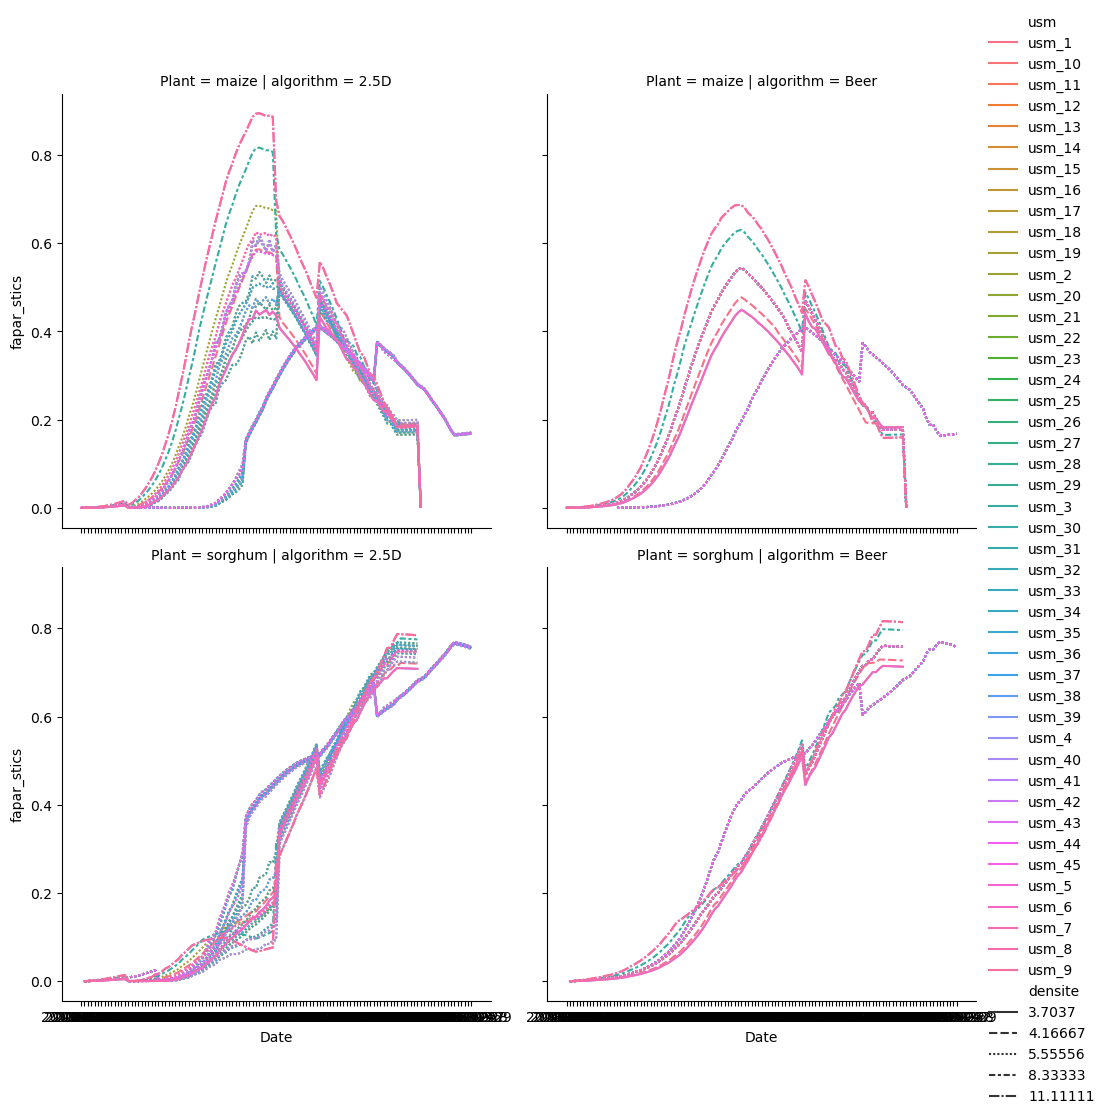

In [3]:
sns.relplot(
    data=df_stics,
    x="Date", 
    y="fapar_stics",
    hue="usm",
    row="Plant",
    col="algorithm",
    style="densite",
    kind="line",
)

'''
g = sns.relplot(
    data=fmri,
    x="timepoint", y="signal",
    hue="event", style="event", col="region",
    height=4, aspect=.7, kind="line"
)
(g.map(plt.axhline, y=0, color=".7", dashes=(2, 1), zorder=0)
  .set_axis_labels("Timepoint", "Percent signal change")
  .set_titles("Region: {col_name} cortex")
  .tight_layout(w_pad=0))
'''

In [3]:
df_doe = pd.read_csv("../../1-simul_stics/2-outputs/doe.csv")

df_doe["usm"] = [f"usm_{i}" for i in range(1,len(df_doe)+1)]

df_doe

,species_id,species_principal,species_secondary,design,row_orientation,interrow_distance_principal,interrow_distance_secondary,n_rows_principal,n_rows_secondary,intrarow_distance,sowing_date_latest_crop,usm
0,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,high,same,usm_1
1,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,middle,same,usm_2
2,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,low,same,usm_3
3,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,N-S,high,high,one,one,middle,same,usm_4
4,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,N-S,middle,middle,one,one,middle,same,usm_5
5,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,N-S,low,low,one,one,middle,same,usm_6
6,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,high,high,one,one,middle,same,usm_7
7,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,middle,middle,one,one,middle,same,usm_8
8,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same,usm_9
9,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same,usm_10


In [4]:
directory = Path("../0-data/")

for i,file in enumerate(directory.glob("*.csv")):

    # Read the CSV file
    df = pd.read_csv(file)
    
    # Keep only maize and sorghum
    crop_df = df[df["group"].isin(["maize", "sorghum"])]
    
    # Calculate average fAPAR for each group at each time step
    average_fapar = (
        crop_df
        .groupby(["group", "step_number"], as_index=False)["fapar"]
        # .mean()
        .sum()
        .rename(columns={"fapar": "sum_fapar"})
    )

    fn = Path(file).stem
    u = re.search(r"usm_\d+", fn).group()
    average_fapar["usm"] = u
    average_fapar["algo"] = "2.5D" if i%2==0 else "Beer"

    if i==0:
        conc_df = average_fapar
    else:
        conc_df = pd.concat([conc_df, average_fapar], ignore_index=True)
        

    # print(average_fapar)

In [5]:
conc_df

,group,step_number,sum_fapar,usm,algo
0,maize,1,0.000977,usm_10,2.5D
1,maize,2,0.001464,usm_10,2.5D
2,maize,3,0.002019,usm_10,2.5D
3,maize,4,0.002865,usm_10,2.5D
4,maize,5,0.003933,usm_10,2.5D
...,...,...,...,...,...
18170,sorghum,98,0.911272,usm_9,Beer
18171,sorghum,99,0.911317,usm_9,Beer
18172,sorghum,100,0.911588,usm_9,Beer
18173,sorghum,101,0.911455,usm_9,Beer


In [14]:
merged = pd.merge(conc_df, df_doe, on="usm")

In [15]:
merged

,group,step_number,sum_fapar,usm,algo,species_id,species_principal,species_secondary,design,row_orientation,interrow_distance_principal,interrow_distance_secondary,n_rows_principal,n_rows_secondary,intrarow_distance,sowing_date_latest_crop
0,maize,1,0.000977,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
1,maize,2,0.001464,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
2,maize,3,0.002019,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
3,maize,4,0.002865,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
4,maize,5,0.003933,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18170,sorghum,98,0.911272,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same
18171,sorghum,99,0.911317,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same
18172,sorghum,100,0.911588,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same
18173,sorghum,101,0.911455,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same


In [16]:
dist = {"low":0.2, "middle":0.4, "high":0.8}
n_rows = {"one":1, "low":2, "middle":4, "high":6}

merged["species"] = merged["group"]
merged["DAE"] = merged["step_number"]
merged["interrow_sorghum"] = [dist[i] for i in merged["interrow_distance_principal"]] 
merged["interrow_maize"] = [dist[i] for i in merged["interrow_distance_secondary"]]
merged["intrarow"] = [dist[i] for i in merged["intrarow_distance"]]
merged["n_rows_sorghum"] = [n_rows[i] for i in merged["n_rows_principal"]]
merged["n_rows_maize"] = [n_rows[i] for i in merged["n_rows_secondary"]]
merged["density_sorghum"] = 1/merged["interrow_sorghum"]/merged["intrarow"]
merged["density_maize"] = 1/merged["interrow_maize"]/merged["intrarow"]
# merged["nb_plants_sorghum"] = [2 if merged.iloc[i]["design"] == "intercrop mixed" else merged.iloc[i]["n_rows_sorghum"] for i in range(len(merged))]
# merged["nb_plants_maize"] = [2 if merged.iloc[i]["design"] == "intercrop mixed" else merged.iloc[i]["n_rows_maize"] for i in range(len(merged))]
merged["width"] = [2 * merged.iloc[i]["interrow_sorghum"] if merged.iloc[i]["design"] == "intercrop mixed" else (merged.iloc[i]["n_rows_sorghum"]-1) * merged.iloc[i]["interrow_sorghum"] + (merged.iloc[i]["n_rows_maize"]-1) * merged.iloc[i]["interrow_maize"] + 2*max(merged.iloc[i]["interrow_sorghum"], merged.iloc[i]["interrow_maize"]) for i in range(len(merged))]
merged["length"] = [2 * max(merged.iloc[i]["intrarow"], merged.iloc[i]["intrarow"]) if merged.iloc[i]["design"] == "intercrop mixed" else max(merged.iloc[i]["intrarow"], merged.iloc[i]["intrarow"]) for i in range(len(merged))]
merged["domain_area"] = merged["width"] * merged["length"]
merged["fapar_crop"] = merged["sum_fapar"] / merged["domain_area"]

merged

,group,step_number,sum_fapar,usm,algo,species_id,species_principal,species_secondary,design,row_orientation,...,interrow_maize,intrarow,n_rows_sorghum,n_rows_maize,density_sorghum,density_maize,width,length,domain_area,fapar_crop
0,maize,1,0.000977,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.000509
1,maize,2,0.001464,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.000763
2,maize,3,0.002019,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.001052
3,maize,4,0.002865,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.001492
4,maize,5,0.003933,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.002048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18170,sorghum,98,0.911272,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.695449
18171,sorghum,99,0.911317,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.695729
18172,sorghum,100,0.911588,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.697423
18173,sorghum,101,0.911455,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.696592


In [17]:
merged = merged.drop(columns=["species_id","species_principal","species_secondary","group"])
merged

,step_number,sum_fapar,usm,algo,design,row_orientation,interrow_distance_principal,interrow_distance_secondary,n_rows_principal,n_rows_secondary,...,interrow_maize,intrarow,n_rows_sorghum,n_rows_maize,density_sorghum,density_maize,width,length,domain_area,fapar_crop
0,1,0.000977,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.000509
1,2,0.001464,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.000763
2,3,0.002019,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.001052
3,4,0.002865,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.001492
4,5,0.003933,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.002048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18170,98,0.911272,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.695449
18171,99,0.911317,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.695729
18172,100,0.911588,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.697423
18173,101,0.911455,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.696592


In [18]:
simultaneous = merged[merged["sowing_date_latest_crop"] == "same"]

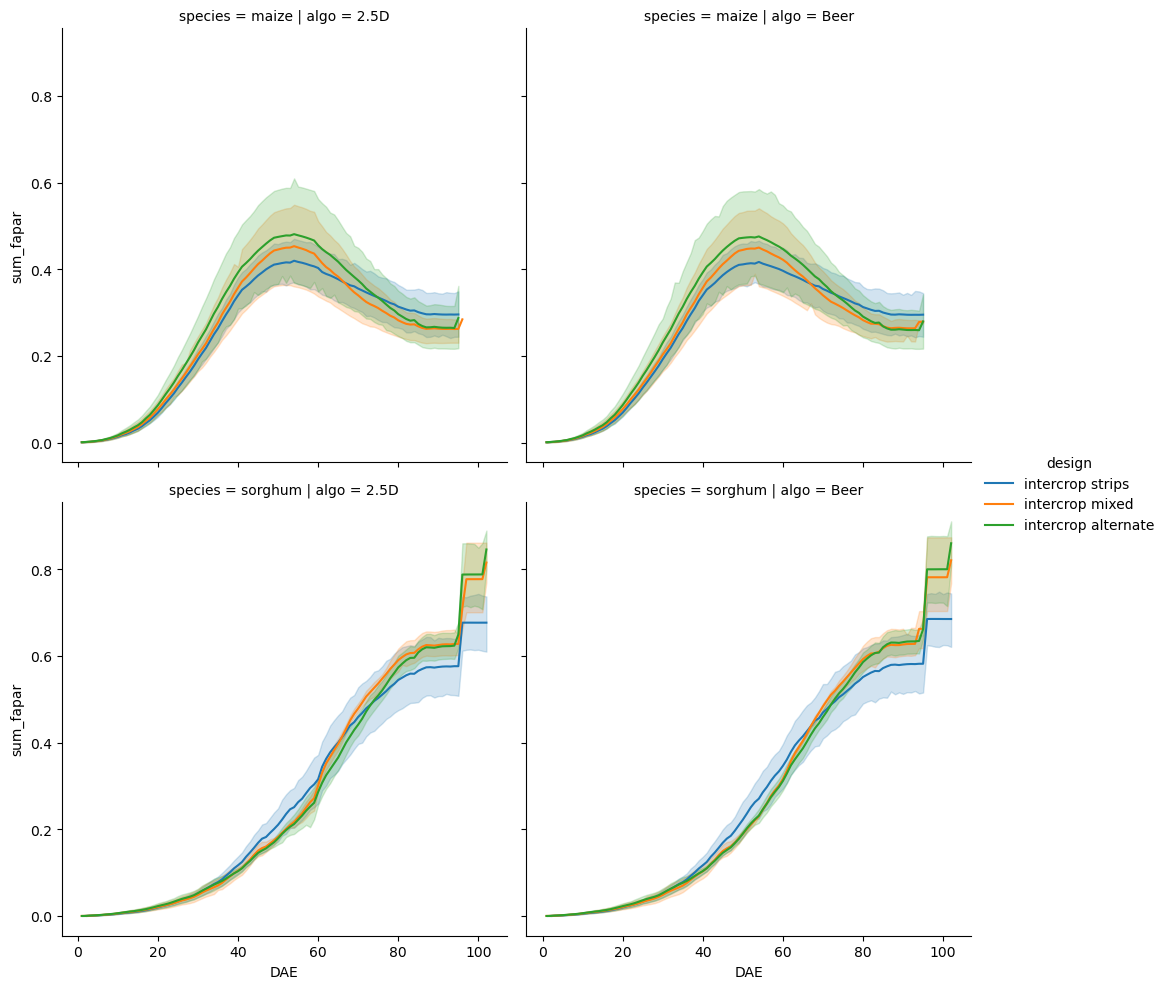

In [19]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="sum_fapar",
    hue="design",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/light_designs.png')

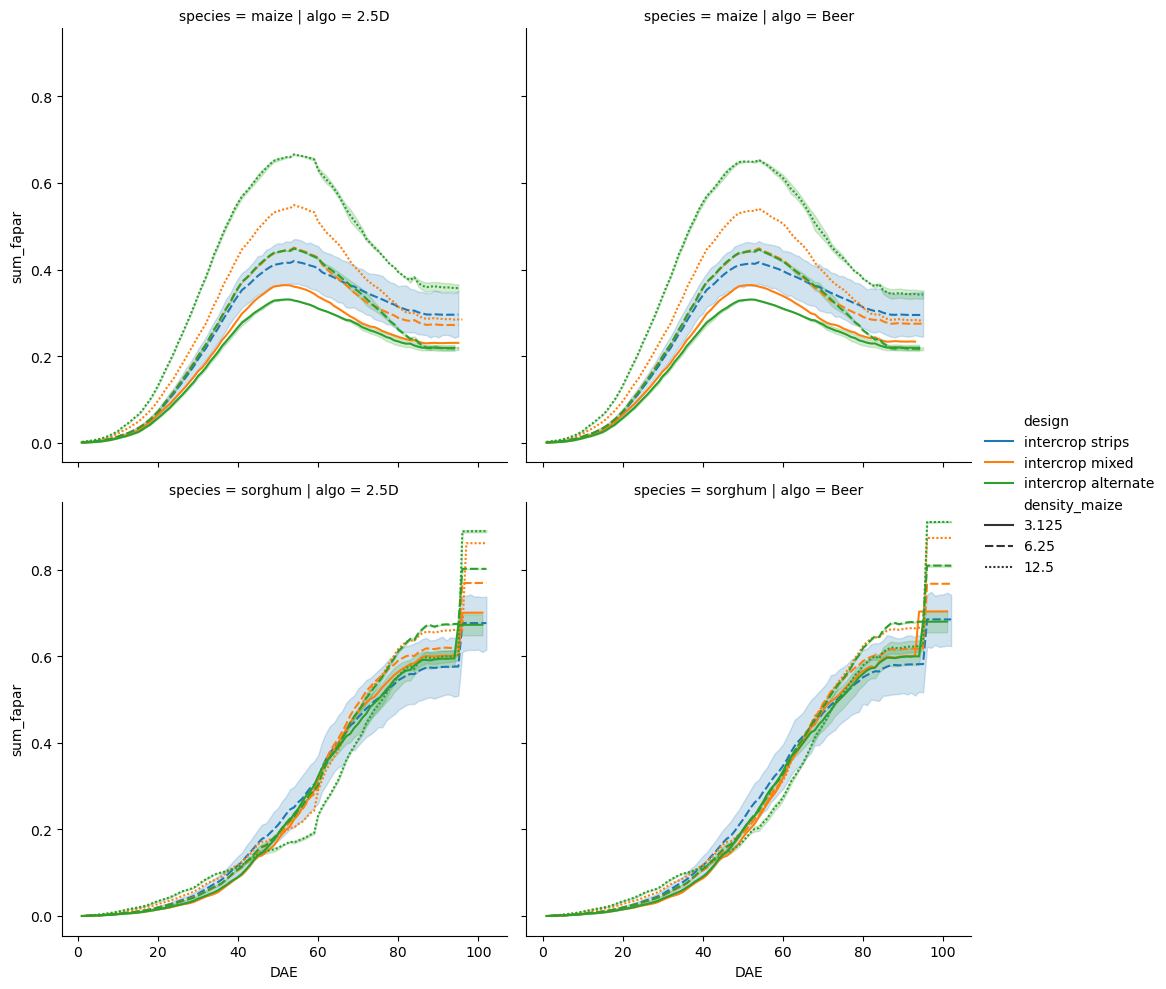

In [20]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="sum_fapar",
    hue="design",
    row="species",
    col="algo",
    style="density_maize",
    kind="line",
)

plot.savefig('../2-outputs/light_designs_density.png')

In [21]:
simultaneous

,step_number,sum_fapar,usm,algo,design,row_orientation,interrow_distance_principal,interrow_distance_secondary,n_rows_principal,n_rows_secondary,...,interrow_maize,intrarow,n_rows_sorghum,n_rows_maize,density_sorghum,density_maize,width,length,domain_area,fapar_crop
0,1,0.000977,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.000509
1,2,0.001464,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.000763
2,3,0.002019,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.001052
3,4,0.002865,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.001492
4,5,0.003933,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.002048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18170,98,0.911272,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.695449
18171,99,0.911317,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.695729
18172,100,0.911588,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.697423
18173,101,0.911455,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.696592


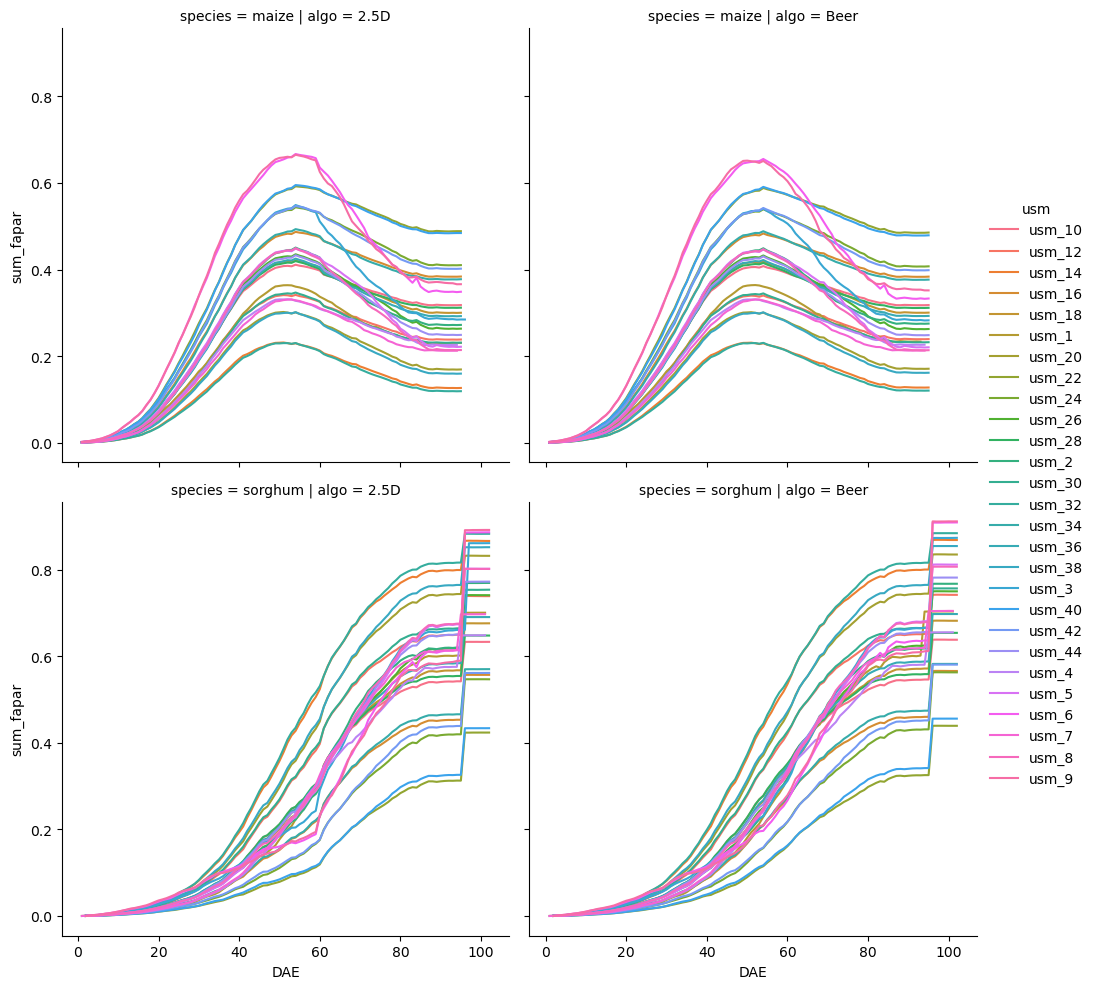

In [22]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="sum_fapar",
    hue="usm",
    row="species",
    col="algo",
    kind="line",
)

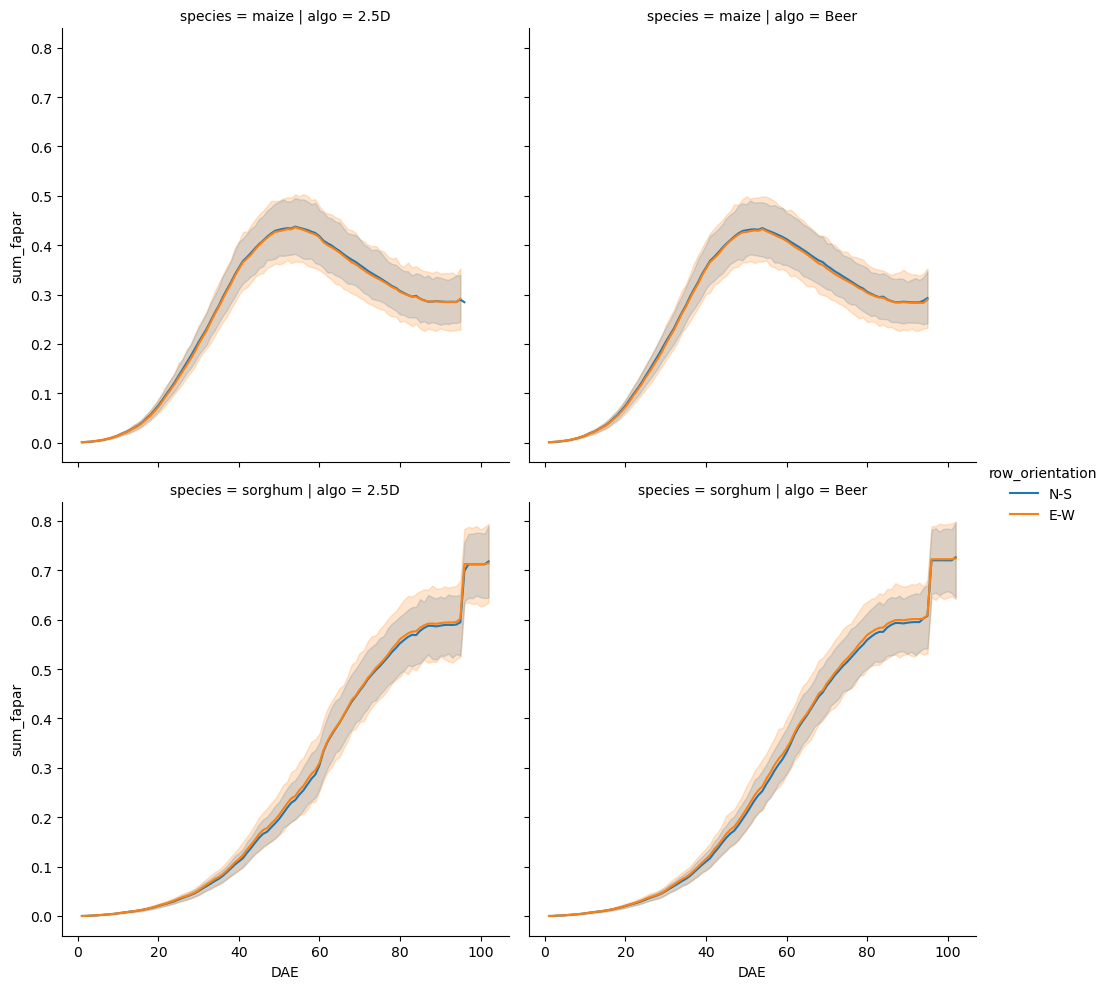

In [23]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="sum_fapar",
    hue="row_orientation",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/light_orientation.png')

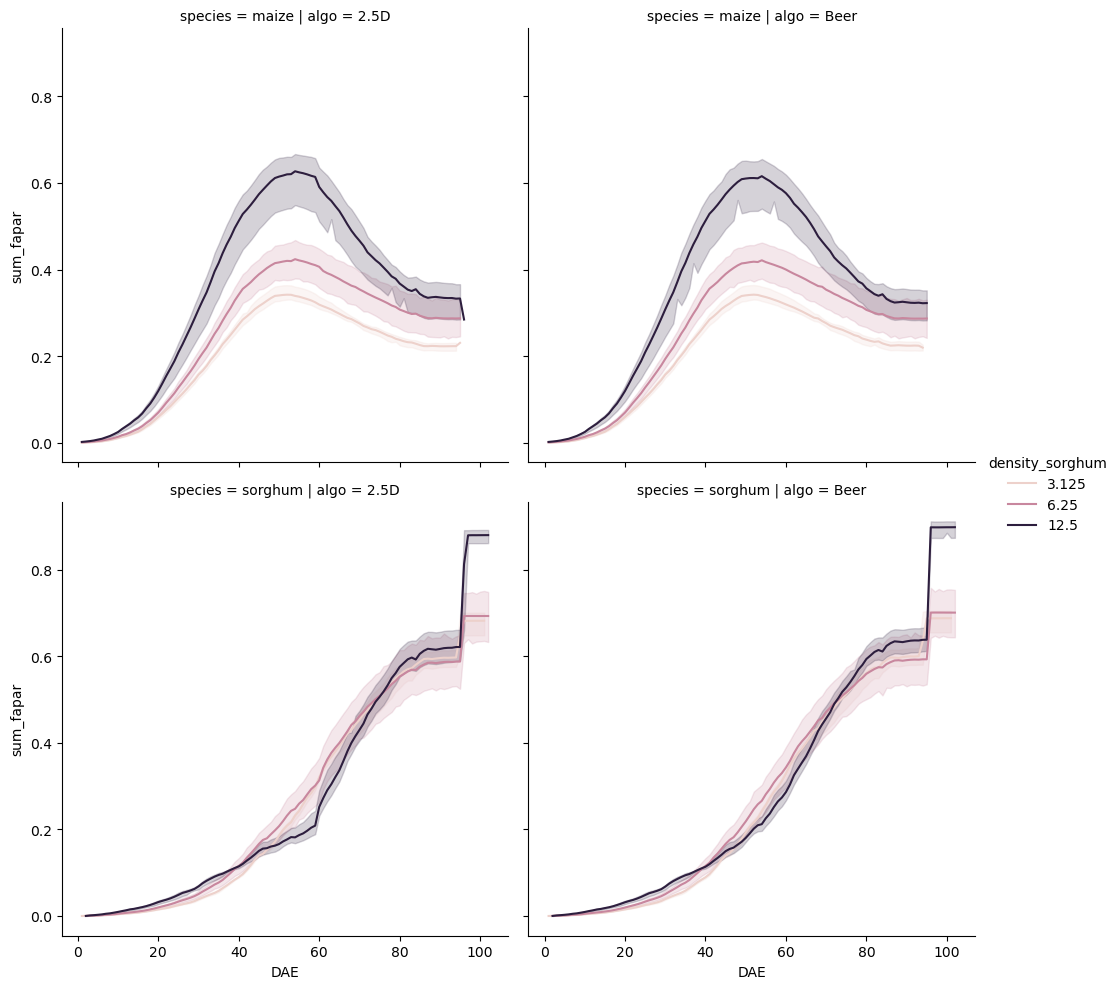

In [24]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="sum_fapar",
    hue="density_sorghum",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/light_density.png')

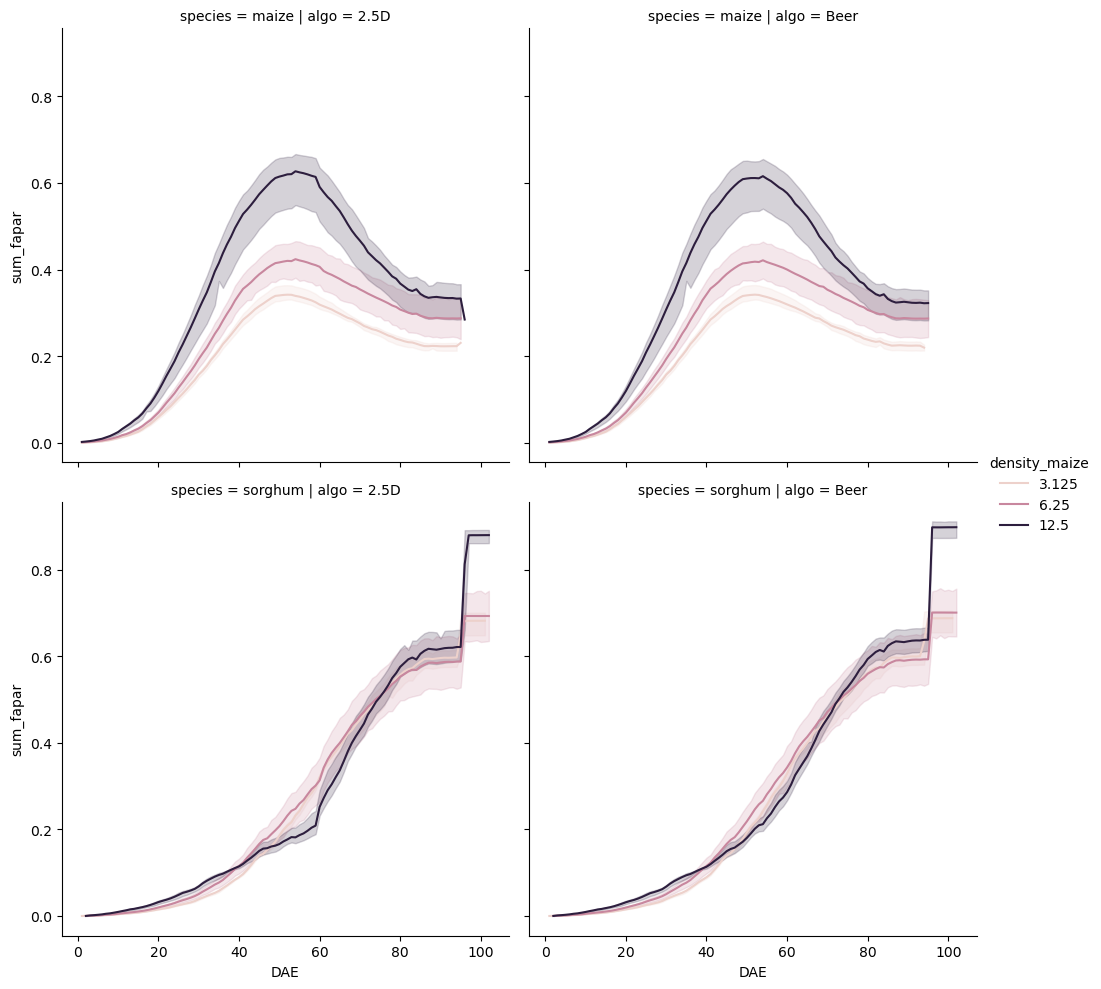

In [25]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="sum_fapar",
    hue="density_maize",
    row="species",
    col="algo",
    kind="line",
)

In [26]:
strips = merged[merged["design"] == "intercrop strips"]

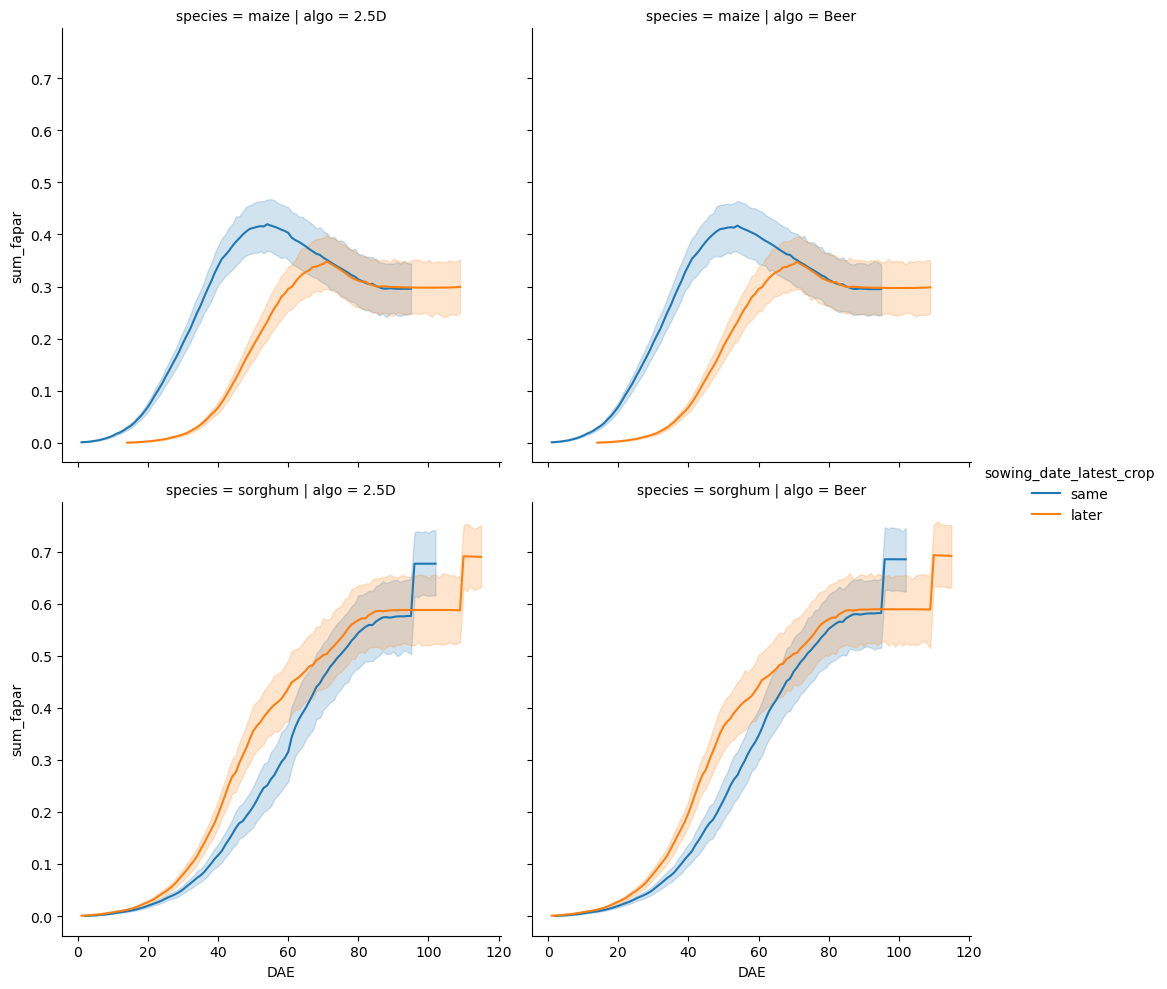

In [27]:
plot = sns.relplot(
    data=strips,
    x="DAE", 
    y="sum_fapar",
    hue="sowing_date_latest_crop",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/light_sowing_date.png')

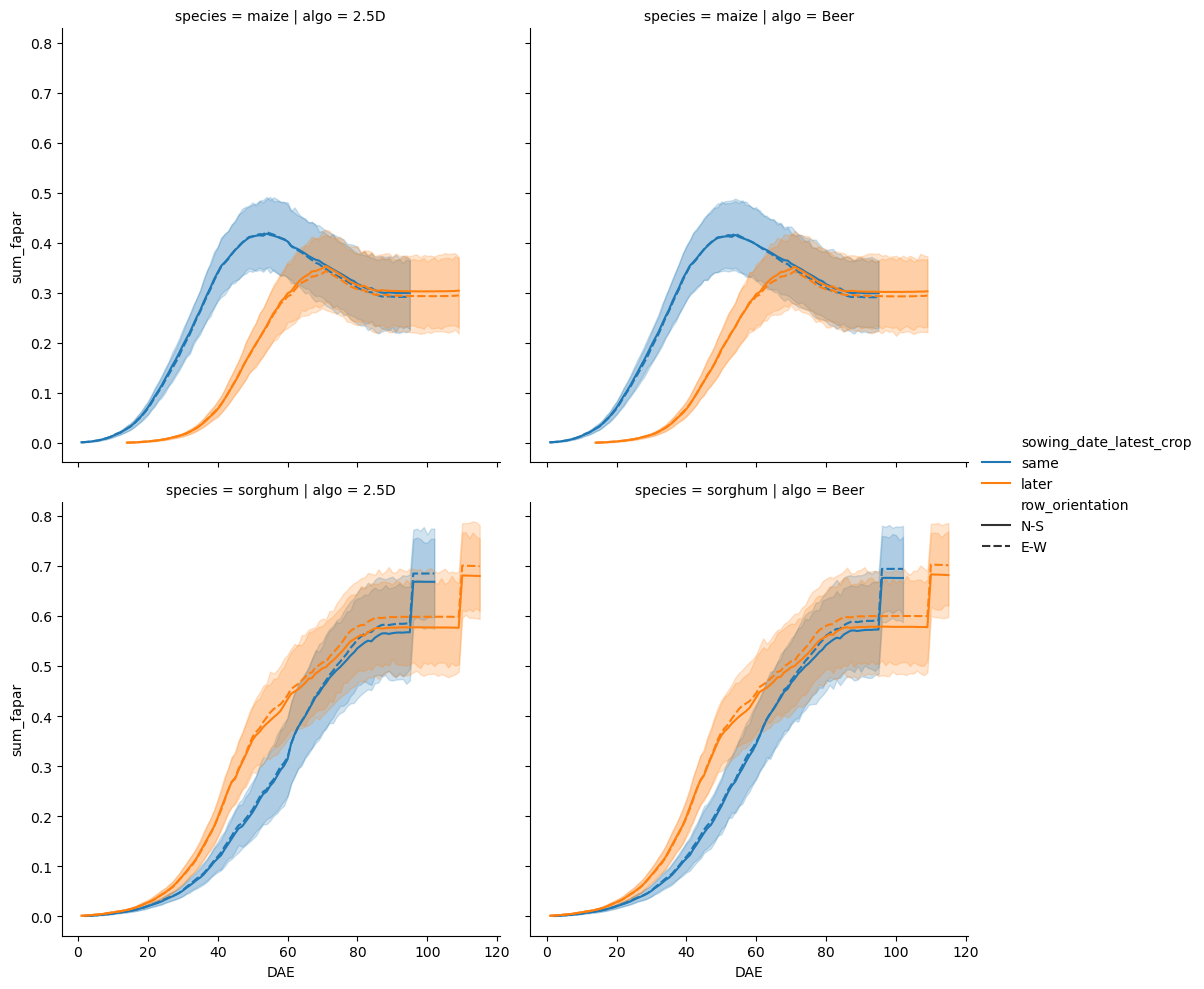

In [28]:
plot = sns.relplot(
    data=strips,
    x="DAE", 
    y="sum_fapar",
    hue="sowing_date_latest_crop",
    style="row_orientation",
    row="species",
    col="algo",
    kind="line",
)